# Projection-Effect Bias Models: Usage Examples

This notebook demonstrates how to use the two projection-effect bias models implemented in
`crow/cluster_modules/projection_effects/`:

* **`CostanziRichnessBias`** (`richness_bias.py`) — models the projection effect on cluster
  richness, i.e. the probability of observing a richness $\lambda_{\mathrm{ob}}$ given a true
  richness $\lambda_{\mathrm{tr}}$, following [Costanzi et al. 2019 (arXiv:1807.07072)](https://arxiv.org/abs/1807.07072).
* **`CostanziLensingBias`** (`lensing_bias.py`) — models the multiplicative selection-bias
  correction $B_{\mathrm{sel}}(R)$ applied to stacked $\Delta\Sigma$ lensing profiles, following [Costanzi et al. 2026 (arXiv:2604.05833)](https://arxiv.org/abs/2604.05833)., Equation C1.

Both classes store their model parameters in a `Parameters` container (`model.parameters`),
which can be updated at any time with `model.parameters.update({...})`.


In [1]:
import os
# turn off OpenMP to keep the notebook deterministic and light-weight
os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
import matplotlib.pyplot as plt

from crow.cluster_modules.projection_effects import CostanziLensingBias, CostanziRichnessBias
from crow.cluster_modules.projection_effects.richness_bias import RICHNESS_BIAS_DEFAULT_PARAMETERS
from crow.cluster_modules.projection_effects.lensing_bias import LENSING_BIAS_DEFAULT_PARAMETERS

## 1. `CostanziRichnessBias` — richness projection effects

The observed richness is modeled as $\lambda_{\mathrm{ob}} \sim \lambda_{\mathrm{tr}} + \mathcal{N}(\delta\mu, \sigma_{\mathrm{pure}})$
plus an exponential tail from chance projections, controlled by the parameters `tau`,
`delta_mu`, `fractional_sig_pure`, `fprj`, and `fmsk`.

Following Costanzi+19 (Eq. 15)[^1], the probability of observing richness $\lambda_{\mathrm{ob}}$
given true richness $\lambda_{\mathrm{tr}}$ is:

$$
P(\lambda_{\mathrm{ob}} \mid \lambda_{\mathrm{tr}}) = (1-f_{\mathrm{msk}})(1-f_{\mathrm{prj}})\frac{e^{-(\lambda_{\mathrm{ob}}-\mu)^2/2\sigma^2}}{\sqrt{2\pi\sigma^2}}
$$

$$
+\ \frac{1}{2}\left[(1-f_{\mathrm{msk}})f_{\mathrm{prj}}\tau + \frac{f_{\mathrm{msk}}f_{\mathrm{prj}}}{\lambda_{\mathrm{tr}}}\right]
e^{\frac{\tau}{2}(2\mu+\tau\sigma^2-2\lambda_{\mathrm{ob}})}\,
\mathrm{erfc}\!\left(\frac{\mu+\tau\sigma^2-\lambda_{\mathrm{ob}}}{\sqrt{2}\,\sigma}\right)
$$

$$
+\ \frac{f_{\mathrm{msk}}}{2\lambda_{\mathrm{tr}}}\left[
\mathrm{erfc}\!\left(\frac{\mu-\lambda_{\mathrm{ob}}-\lambda_{\mathrm{tr}}}{\sqrt{2}\,\sigma}\right)
- \mathrm{erfc}\!\left(\frac{\mu-\lambda_{\mathrm{ob}}}{\sqrt{2}\,\sigma}\right)
\right]
$$

$$
-\ \frac{f_{\mathrm{msk}}f_{\mathrm{prj}}}{2\lambda_{\mathrm{tr}}}
e^{-\tau\lambda_{\mathrm{tr}}}\,e^{\frac{\tau}{2}(2\mu+\tau\sigma^2-2\lambda_{\mathrm{ob}})}\,
\mathrm{erfc}\!\left(\frac{\mu+\tau\sigma^2-\lambda_{\mathrm{ob}}-\lambda_{\mathrm{tr}}}{\sqrt{2}\,\sigma}\right)
$$

where $\mu = \lambda_{\mathrm{tr}} + \delta\mu$ and $\sigma_{\mathrm{pure}} = f_{\mathrm{sig,pure}}\,\lambda_{\mathrm{tr}}$
(written as $\sigma$ above for brevity).

[^1]: Costanzi et al. 2018, MNRAS, arXiv:1807.07072, Equation 15. Verified term-by-term
against the `prob_richobs_at_richtru` implementation.

### 1.1 Evaluating $P(\lambda_{\mathrm{ob}} \mid \lambda_{\mathrm{tr}})$ for a single true richness

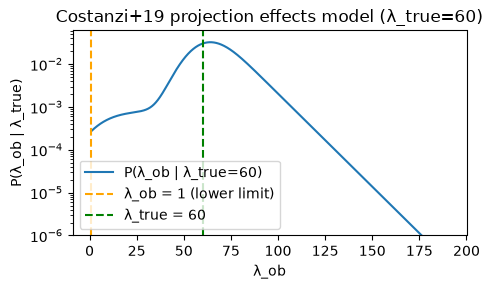

In [2]:
# Observed-richness grid on which the PDF is evaluated
lowerlimit = 1
rich_obs = np.linspace(lowerlimit, 200, 10000)
single_tru_richness = 60
rich_tru = np.array([single_tru_richness]) # a single true richness

# Create the model and anchor its parameters (defaults shown here for clarity)
richness_model = CostanziRichnessBias(**RICHNESS_BIAS_DEFAULT_PARAMETERS)
richness_model.parameters.update(
    {
        "tau": 0.10,
        "delta_mu": -2.0,
        "fractional_sig_pure": 0.15,
        "fprj": 0.95,
        "fmsk": 0.05,
    }
)

# pdf has shape (len(rich_obs), len(rich_tru))
pdf = richness_model.prob_richobs_at_richtru(rich_obs=rich_obs, rich_tru=rich_tru)

plt.figure(figsize=(5, 3))
plt.plot(rich_obs, pdf[:, 0], label=f"P(λ_ob | λ_true={single_tru_richness})")
plt.axvline(x=lowerlimit, color="orange", linestyle="--", label=f"λ_ob = {lowerlimit} (lower limit)")
plt.axvline(x=single_tru_richness, color="green", linestyle="--", label=f"λ_true = {single_tru_richness}")
plt.yscale("log")
plt.xlabel("λ_ob")
plt.ylabel("P(λ_ob | λ_true)")
plt.title(f"Costanzi+19 projection effects model (λ_true={single_tru_richness})")
plt.legend()
plt.xlim(lowerlimit-10, 200)
plt.ylim(1e-6, None)
plt.tight_layout()
plt.show()

### 1.2 Evaluating the PDF for several true-richness values at once

pdf shape: (10000, 3)


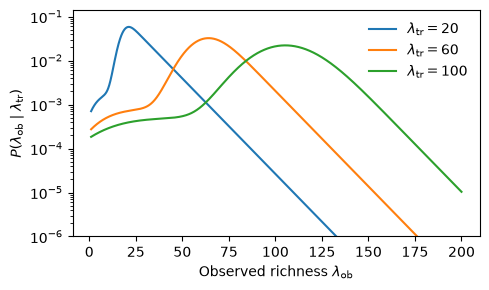

In [3]:
rich_tru_array = np.array([20.0, 60.0, 100.0])

pdf = richness_model.prob_richobs_at_richtru(rich_obs=rich_obs, rich_tru=rich_tru_array)
print("pdf shape:", pdf.shape)  # (len(rich_obs), len(rich_tru_array))

plt.figure(figsize=(5, 3))
for i, lam_tr in enumerate(rich_tru_array):
    plt.plot(rich_obs, pdf[:, i], label=rf"$\lambda_{{\mathrm{{tr}}}}={lam_tr:g}$")
plt.xlabel(r"Observed richness $\lambda_{\mathrm{ob}}$")
plt.ylabel(r"$P(\lambda_{\mathrm{ob}} \mid \lambda_{\mathrm{tr}})$")
plt.yscale("log")
plt.ylim(1e-6, None)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

### 1.3 Per-bin parameters (arrays instead of scalars)

Every parameter may instead be a 1D array broadcastable to `rich_tru`, which is useful when the
projection-effect calibration itself depends on true richness.

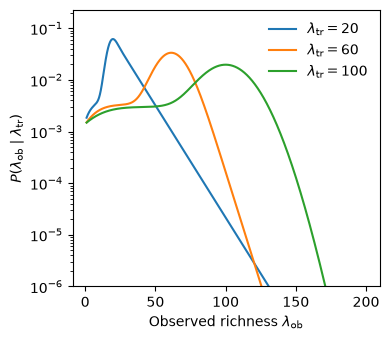

In [4]:
richness_model.parameters.update(
    {
        "tau": np.array([0.10, 0.20, 0.30]),
        "delta_mu": -2.0,
        "fractional_sig_pure": 0.15,
        "fprj": np.array([0.80, 0.90, 0.95]),
        "fmsk": np.array([0.10, 0.20, 0.30]),
    }
)

pdf = richness_model.prob_richobs_at_richtru(rich_obs=rich_obs, rich_tru=rich_tru_array)

plt.figure(figsize=(4, 3.5))
for i, lam_tr in enumerate(rich_tru_array):
    plt.plot(rich_obs, pdf[:, i], label=rf"$\lambda_{{\mathrm{{tr}}}}={lam_tr:g}$")
plt.xlabel(r"Observed richness $\lambda_{\mathrm{ob}}$")
plt.ylabel(r"$P(\lambda_{\mathrm{ob}} \mid \lambda_{\mathrm{tr}})$")
plt.yscale("log")
plt.ylim(1e-6, None)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

### 1.4 Integrating the PDF over observed-richness bins

`Sprob_at_richtru` integrates $P(\lambda_{\mathrm{ob}} \mid \lambda_{\mathrm{tr}})$ over bins defined by
`rich_obs_eds`, which is what is typically needed to predict binned cluster counts.

      Bin range | λ_tr=20 | λ_tr=60 | λ_tr=100
[ 10.0,  30.0) | 0.7080 | 0.0280 | 0.0154
[ 30.0,  45.0) | 0.2041 | 0.0471 | 0.0143
[ 45.0,  60.0) | 0.0455 | 0.2781 | 0.0167
[ 60.0,  80.0) | 0.0113 | 0.5020 | 0.0680
[ 80.0, 110.0) | 0.0017 | 0.1267 | 0.4992


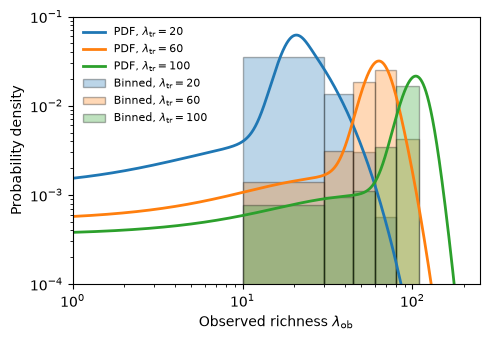

In [5]:
# Observed-richness grid (log-spaced, spans full plot range)
rich_obs = np.geomspace(lowerlimit, 250, 10000)
rich_tru_array = np.array([20.0, 60.0, 100.0])  # example: multiple true-richness values

richness_model.parameters.update(
    {
        "tau": 0.10,
        "delta_mu": -1.0,
        "fractional_sig_pure": 0.15,
        "fprj": 0.80,
        "fmsk": 0.10,
    }
)
pdf = richness_model.prob_richobs_at_richtru(rich_obs=rich_obs, rich_tru=rich_tru_array)
# Example bin edges (arbitrary, for illustration only — not the analysis bins)
edges = np.array([10.0, 30.0, 45.0, 60.0, 80.0, 110.0])
resolution = 0.01  # fractional step size used in the internal integration grid
integrated_prob = richness_model.Sprob_at_richtru(
    rich_obs_eds=edges,
    rich_obs_res=resolution,
    rich_tru=rich_tru_array,
)
bin_centers = np.sqrt(edges[:-1] * edges[1:])  # geometric mean, consistent with internal binning
bin_widths = np.diff(edges)

plt.figure(figsize=(5, 3.5))
for i, lam_tr in enumerate(rich_tru_array):
    plt.plot(rich_obs, pdf[:, i], lw=2, label=rf"PDF, $\lambda_{{\mathrm{{tr}}}}={lam_tr:g}$")
    plt.bar(
        edges[:-1],                              
        integrated_prob[:, i] / bin_widths,
        width=bin_widths,
        align="edge",                             
        alpha=0.3,
        edgecolor="black",
        label=rf"Binned, $\lambda_{{\mathrm{{tr}}}}={lam_tr:g}$",
    )

plt.xlabel(r"Observed richness $\lambda_{\mathrm{ob}}$")
plt.ylabel("Probability density")
plt.loglog()
plt.xlim(lowerlimit, 250)
plt.ylim(1e-4, 0.1)
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()

# Print the probability mass in each bin for each true richness
print(f"{'Bin range':>15} | " + " | ".join(f"λ_tr={lt:g}" for lt in rich_tru_array))
for j in range(len(edges) - 1):
    row = " | ".join(f"{integrated_prob[j, i]:.4f}" for i in range(len(rich_tru_array)))
    print(f"[{edges[j]:>5.1f}, {edges[j+1]:>5.1f}) | {row}")

plt.show()

## 2. `CostanziLensingBias` — lensing profile selection bias

`CostanziLensingBias` evaluates the multiplicative correction

$$B_{\mathrm{sel}}(R) = 1 + A_{\mathrm{sel}} \left(\frac{R}{R_{0,\mathrm{sel}}}\right)^{\alpha_{\mathrm{sel}}}
\left[1 + \left(\frac{R}{R_{0,\mathrm{sel}}}\right)^{\gamma_{\mathrm{sel}}}\right]^{(\beta_{\mathrm{sel}} - \alpha_{\mathrm{sel}})/\gamma_{\mathrm{sel}}}$$

that should be applied to a stacked $\Delta\Sigma$ profile after it has been integrated over the
selected cluster population. The default parameters (`A_sel=0`) give a neutral correction,
$B_{\mathrm{sel}}(R) = 1$.

### 2.1 A single calibration, evaluated in comoving Mpc/h

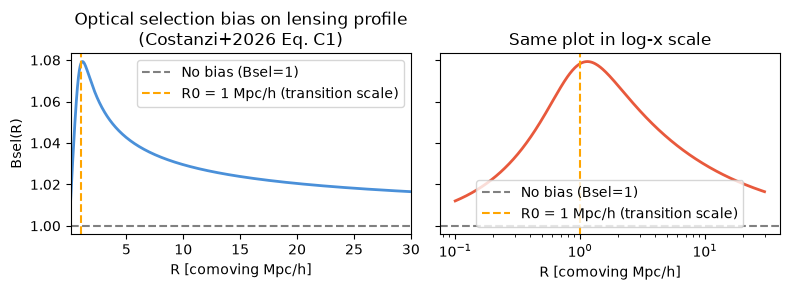

In [6]:

model = CostanziLensingBias(
    A_sel=0.10,
    alpha_sel=0.92,
    beta_sel=-0.53,
    gamma_sel=4.1,
    R0_sel=1.0,
    # reference_redshift omitted: only needed when radial_units="Mpc" (physical)
)

radius = np.geomspace(0.1, 30, 500)  # comoving Mpc/h
bsel = model.bsel(radius, radial_units="Mpc/h")

fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
for ax, xscale, color in zip(axes, ["linear", "log"], ["#4A90D9", "#E8593C"]):
    ax.plot(radius, bsel[0], color=color, lw=2)
    ax.axhline(y=1.0, color="gray", linestyle="--", label="No bias (Bsel=1)")
    ax.axvline(x=1.0, color="orange", linestyle="--", label="R0 = 1 Mpc/h (transition scale)")
    ax.set_xlabel("R [comoving Mpc/h]")
    ax.set_xscale(xscale)
    ax.legend()

axes[0].set_ylabel("Bsel(R)")
axes[0].set_title("Optical selection bias on lensing profile\n(Costanzi+2026 Eq. C1)")
axes[1].set_title("Same plot in log-x scale")
axes[0].set_xlim(0.1, 30)
plt.tight_layout()
plt.show()

### 2.2 Several richness–redshift bins at once

`A_sel`, `alpha_sel`, `beta_sel`, `gamma_sel`, and `R0_sel` can each be 1D arrays of the same
length, one entry per calibrated richness–redshift bin. `bsel` then returns one row per bin.

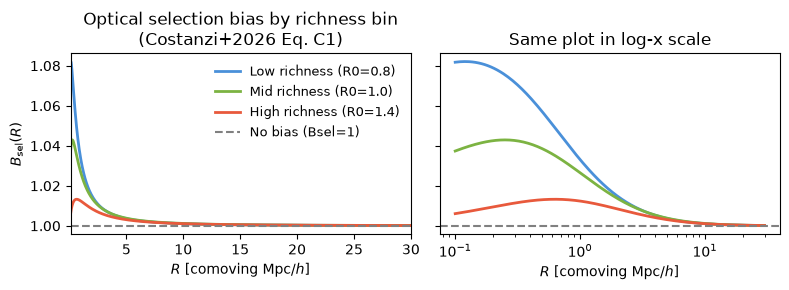

In [7]:
radius = np.geomspace(0.1, 30, 200)  # comoving Mpc/h

lensing_model_bins = CostanziLensingBias(
    A_sel=[0.20, 0.15, 0.08],
    alpha_sel=[0.3, 0.5, 0.9],
    beta_sel=[-2.0, -2.0, -2.0],
    gamma_sel=[1.0, 1.0, 1.0],
    R0_sel=[0.8, 1.0, 1.4],
)
bsel_bins = lensing_model_bins.bsel(radius, radial_units="Mpc/h")  # shape (3, 200)

labels = ["Low richness", "Mid richness", "High richness"]
colors = ["#4A90D9", "#7CB342", "#E8593C"]
R0_values = [0.8, 1.0, 1.4]

fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

for ax, xscale in zip(axes, ["linear", "log"]):
    for i, (label, color, R0) in enumerate(zip(labels, colors, R0_values)):
        ax.plot(radius, bsel_bins[i], color=color, lw=2, label=f"{label} (R0={R0})")
    ax.axhline(y=1.0, color="gray", linestyle="--", label="No bias (Bsel=1)")
    ax.set_xlabel(r"$R$ [comoving Mpc/$h$]")
    ax.set_xscale(xscale)

axes[0].set_ylabel(r"$B_{\mathrm{sel}}(R)$")
axes[0].set_title("Optical selection bias by richness bin\n(Costanzi+2026 Eq. C1)")
axes[1].set_title("Same plot in log-x scale")
axes[0].set_xlim(0.1, 30)
axes[0].legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

### 2.3 Evaluating at physical Mpc

If the profile radii are given in physical Mpc rather than comoving Mpc/h, pass
`radial_units="Mpc"` together with `cosmo_h`. This requires `reference_redshift` (one value per
parameter set) to have been supplied at construction time, since the physical-to-comoving
conversion is redshift dependent.

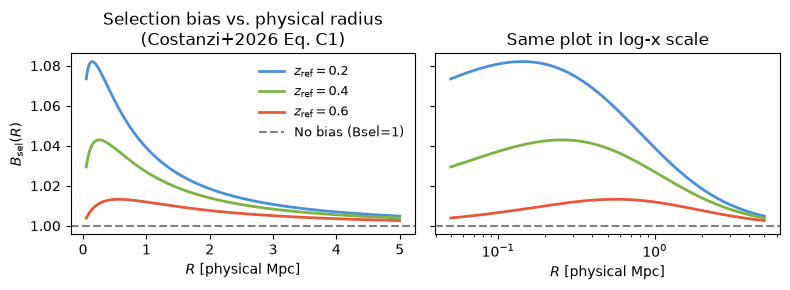

In [9]:
lensing_model_z = CostanziLensingBias(
    A_sel=[0.20, 0.15, 0.08],
    alpha_sel=[0.3, 0.5, 0.9],
    beta_sel=[-2.0, -2.0, -2.0],
    gamma_sel=[1.0, 1.0, 1.0],
    R0_sel=[0.8, 1.0, 1.4],
    reference_redshift=[0.2, 0.4, 0.6],
)

radius_physical = np.geomspace(0.05, 5, 200)  # physical Mpc
bsel_physical = lensing_model_z.bsel(radius_physical, radial_units="Mpc", cosmo_h=0.7)

colors = ["#4A90D9", "#7CB342", "#E8593C"]

fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

for ax, xscale in zip(axes, ["linear", "log"]):
    for i, (z, color) in enumerate(zip([0.2, 0.4, 0.6], colors)):
        ax.plot(radius_physical, bsel_physical[i], color=color, lw=2,
                 label=rf"$z_{{\mathrm{{ref}}}}={z}$")
    ax.axhline(y=1.0, color="gray", linestyle="--", label="No bias (Bsel=1)")
    ax.set_xlabel(r"$R$ [physical Mpc]")
    ax.set_xscale(xscale)

axes[0].set_ylabel(r"$B_{\mathrm{sel}}(R)$")
axes[0].set_title("Selection bias vs. physical radius\n(Costanzi+2026 Eq. C1)")
axes[1].set_title("Same plot in log-x scale")
axes[0].legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()